In [1]:
from ipywidgets import interact
import joblib
from joblib import Parallel, delayed

import cartopy.crs as ccrs
import dask.dataframe as dd
from dask_ml.wrappers import ParallelPostFit
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

from lib.main import *
from lib.plot import *

from parameters import parameters

In [2]:
# Plate model name
plate_model_name = parameters["plate_model_name"]

# Timespan for analysis
temporal_resolution = parameters["temporal_resolution"]
time_min = parameters["timespan"]["min"]
time_max = parameters["timespan"]["max"]
time_steps = range(time_min, time_max + temporal_resolution, temporal_resolution)

columns_to_drop_target = parameters["columns_to_drop_target"]

plate_model_dir = parameters["plate_model_dir"]
inputs_dir = parameters["inputs_dir"]
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]
prob_grids_dir = parameters["prob_grids_dir"]
prob_maps_dir = parameters["prob_maps_dir"]

Xy_train_new_filename = parameters["Xy_train_new_filename"]
Xy_rf_train_filename = parameters["Xy_rf_train_filename"]
Xy_rf_test_filename = parameters["Xy_rf_test_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
importances_filename = parameters["importances_filename"]
target_data_filename = parameters["target_data_filename"]
target_prob_filename = parameters["target_prob_filename"]
deposit_recon_coords_all_filename = parameters["deposit_recon_coords_all_filename"]

model_rf_filename = parameters["model_rf_filename"]
robust_scaler_filename = parameters["robust_scaler_filename"]

ml_dir = os.path.join(outputs_dir, ml_dir)
prob_grids_dir = os.path.join(ml_dir, prob_grids_dir)
prob_maps_dir = os.path.join(ml_dir, prob_maps_dir)

Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)
Xy_rf_train_filename = os.path.join(ml_dir, Xy_rf_train_filename)
Xy_rf_test_filename = os.path.join(ml_dir, Xy_rf_test_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
importances_filename = os.path.join(ml_dir, importances_filename)
target_data_filename = os.path.join(outputs_dir, target_data_filename)
target_prob_filename = os.path.join(ml_dir, target_prob_filename)
deposit_recon_coords_all_filename = os.path.join(outputs_dir, deposit_recon_coords_all_filename)

robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)
model_rf_filename = os.path.join(ml_dir, model_rf_filename)

agegrid_dir = os.path.join(inputs_dir, "SeafloorAge")

nprocs = 16

### Random Forest

In [3]:
Xy_train_new = pd.read_csv(Xy_train_new_filename)
# Xy_train_new['label'] = Xy_train_new['label'].replace(2, 1)
Xy_train_new = Xy_train_new[Xy_train_new['label'] != 2]
Xy_train_new_ones = Xy_train_new[Xy_train_new['label'] == 1]
Xy_train_new_zeros = Xy_train_new[Xy_train_new['label'] == 0]
Xy_train_new_zeros_sampled = Xy_train_new_zeros.sample(n=len(Xy_train_new_ones), random_state=42)
Xy_train_new = pd.concat([Xy_train_new_ones, Xy_train_new_zeros_sampled])
Xy_train_new = Xy_train_new.sample(frac=1, random_state=42).reset_index(drop=True)

print('Number of positive samples:', len(Xy_train_new_ones))
print('Number of negative samples:', len(Xy_train_new_zeros_sampled))

features_rf = Xy_train_new.copy()
features_rf = features_rf.drop('label', axis=1)
labels_rf = Xy_train_new['label']

if os.path.isfile(model_rf_filename):
    model_rf = joblib.load(model_rf_filename)
    Xy_rf_test = pd.read_csv(Xy_rf_test_filename)
else:
    # Random Forest model structure
    rf = RandomForestClassifier(n_jobs=nprocs, random_state=42)

    n_fold = 10

    X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(features_rf, labels_rf, train_size=0.8, random_state=42)
    
    Xy_rf_train = np.hstack((X_rf_train, y_rf_train.values.reshape(-1, 1)))
    Xy_rf_train = pd.DataFrame(Xy_rf_train, columns=Xy_train_new.columns)
    Xy_rf_train.to_csv(Xy_rf_train_filename, index=False)
    
    Xy_rf_test = np.hstack((X_rf_test, y_rf_test.values.reshape(-1, 1)))
    Xy_rf_test = pd.DataFrame(Xy_rf_test, columns=Xy_train_new.columns)
    Xy_rf_test.to_csv(Xy_rf_test_filename, index=False)

    weights_rf_train = Xy_rf_train['weight']
    X_rf_train = Xy_rf_train[[col for col in Xy_rf_train.columns if col not in ['weight', 'label']]]
    weights_rf_test = Xy_rf_test['weight']
    X_rf_test = Xy_rf_test[[col for col in Xy_rf_test.columns if col not in ['weight', 'label']]]

    search_space = {
    'bootstrap': Categorical([True, False]),
    'max_depth': Integer(5, 20),
    'max_features': Categorical([None, 'sqrt','log2']), 
    'min_samples_leaf': Integer(2, 20),
    'min_samples_split': Integer(2, 30),
    'n_estimators': Integer(10, 200)
    }

    rf_bayes_search = BayesSearchCV(rf,
                                    search_space,
                                    n_iter=50, # specify how many iterations
                                    scoring='f1',
                                    n_jobs=nprocs,
                                    cv=n_fold,
                                    verbose=1,
                                    random_state=42)
    rf_bayes_search.fit(X_rf_train, y_rf_train, sample_weight=weights_rf_train)
    
    # Extract the optimization results
    optimization_results = rf_bayes_search.cv_results_['mean_test_score']
    
    model_rf = rf_bayes_search.best_estimator_
    model_rf_f1 = rf_bayes_search.best_score_    
    print('The highest F1-score during cross validation:', model_rf_f1)
    
    # Save the model
    joblib.dump(model_rf, model_rf_filename)
    
    # Plot the Bayesian optimization progress
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(optimization_results) + 1), optimization_results, marker='o', color='black', markerfacecolor='red')
    plt.xlim(0, len(optimization_results) + 1)
    plt.xlabel('Bayesian Optimization Iteration')
    plt.ylabel('Mean Test F1 Score')
    plt.title('Bayesian Optimization Progress')
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    # plt.savefig(...)
    plt.show()

Number of positive samples: 971
Number of negative samples: 971


In [4]:
features_rf_test = Xy_rf_test.copy()
features_rf_test = features_rf_test.drop(['weight', 'label'], axis=1)
labels_rf_test = Xy_rf_test['label']
weights_rf_test = Xy_rf_test['weight']

labels_pred = model_rf.predict(features_rf_test)

rf_cmatrix = confusion_matrix(labels_rf_test, labels_pred)
rf_acc = accuracy_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_pre = precision_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_rec = recall_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)
rf_f1 = f1_score(labels_rf_test, labels_pred, sample_weight=weights_rf_test)

print('Confusion matrix:\n', rf_cmatrix)
print('Accuracy:', rf_acc)
print('Precision:', rf_pre)
print('Recall:', rf_rec)
print('F1-Score:', rf_f1)

Confusion matrix:
 [[156  34]
 [ 19 180]]
Accuracy: 0.8569182389937107
Precision: 0.9196217494089834
Recall: 0.8721973094170403
F1-Score: 0.8952819332566168


In [5]:
Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ['weight', 'label']]]
y_pos_test = Xy_pos_test['label']
weights_pos_test = Xy_pos_test['weight']
X_pos_pred = model_rf.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print('Accuracy:', X_pos_pred_acc)

Accuracy: 0.8559027777777778


### ROC Plot

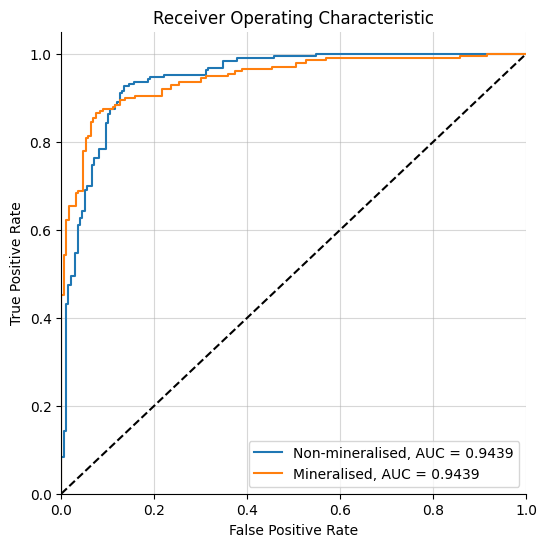

ROC AUC score: 0.9439301772017984


In [6]:
labels_prob = model_rf.predict_proba(features_rf_test)
labels_name = ['Non-mineralised', 'Mineralised']
roc_plot(labels_rf_test, labels_prob, 2, labels_name)

### Feature Importance

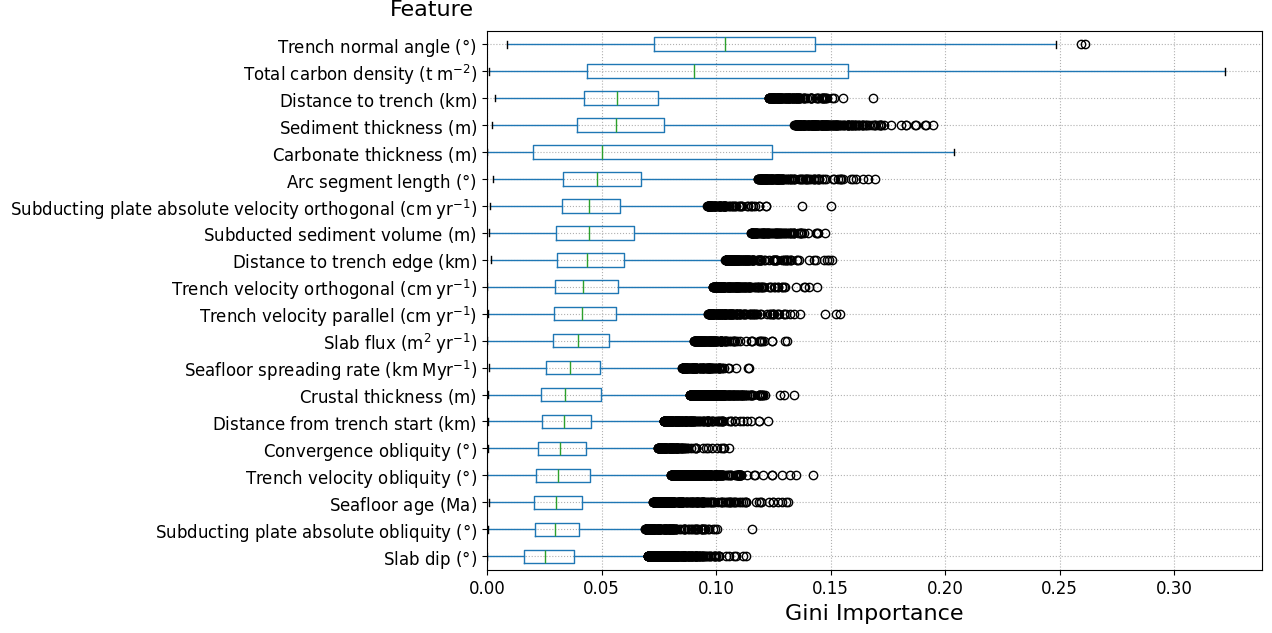

In [7]:
if os.path.isfile(importances_filename):
    importances = pd.read_csv(importances_filename)
else:    
    # Setup
    n_splits = 5
    n_repeats = 10
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=42,
    )
    feature_names = features_rf_test.columns
    importances_all = []

    # Cross-validate with the best estimator
    for idx, _ in cv.split(features_rf, labels_rf):
        features_fold = features_rf.iloc[idx]
        weights_fold = features_fold['weight']
        features_fold = features_fold.drop('weight', axis=1)
        labels_fold = labels_rf.iloc[idx]

        # Clone and fit
        clf = clone(model_rf)
        clf.fit(features_fold, labels_fold, sample_weight=weights_fold)

        # Extract per-tree importances
        tree_importances = pd.DataFrame(
            [tree.feature_importances_ for tree in clf.estimators_],
            columns=feature_names
        )
        importances_all.append(tree_importances)

    # Combine all results into one DataFrame
    importances = pd.concat(importances_all, ignore_index=True)

    # Sort columns by median importance
    importances = importances[importances.median().sort_values(ascending=False).index]

    # Save to CSV
    importances.to_csv(importances_filename, index=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Reverse column order so the most important is on top
importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)

# Customize plot
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel("Gini Importance", fontsize=16)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=16)
ax.yaxis.set_label_coords(-0.017, 1.02)

# Format y-tick labels
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(label.get_text()) for label in ax.get_yticklabels()]
)

# Style tick labels
ax.tick_params(labelsize=12)

plt.show()

### Calculate Probabilities

In [8]:
if os.path.isfile(target_prob_filename):
    target_prob = pd.read_csv(target_prob_filename)
else:
    columns = [
        "lon",
        "lat",
        "present_lon",
        "present_lat",
        "age (Ma)",
    ]

    target_data_dd = dd.read_csv(target_data_filename)
    target_data_out = target_data_dd[columns].compute()

    selected_features = model_rf.feature_names_in_

    robust_scaler = joblib.load(robust_scaler_filename)
    
    target_data = pd.read_csv(target_data_filename)
    target_data_scaled = target_data[selected_features]
    target_data_scaled = robust_scaler.transform(target_data_scaled)
    target_data_scaled = pd.DataFrame(target_data_scaled, columns=selected_features)
    target_data_scaled[columns_to_drop_target] = target_data[columns_to_drop_target]

    try:
        model_rf[-1].set_params(n_jobs=1)
    except ValueError:
        pass
    model_rf_parallel = ParallelPostFit(model_rf)

    target_features = target_data_scaled[selected_features]
    probs = model_rf_parallel.predict_proba(target_features)[:, 1].ravel()
    target_prob = target_data_out.copy()
    target_prob["probability"] = probs
    del probs
    target_prob.to_csv(target_prob_filename, index=False)
    del target_prob

if os.path.exists(prob_grids_dir):
    print(f"Probability grids are located in {prob_grids_dir}")
else:
    os.makedirs(prob_grids_dir, exist_ok=True)

    create_grids(
        data=target_prob_filename,
        output_dir=prob_grids_dir,
        extent=(-180, 180, -90, 90),
        threads=nprocs,
        verbose=True,
    )

Probability grids are located in outputs\ml\prob_grids


In [9]:
plate_model, _tf = get_plate_reconstruction(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    filter_topologies=True,
)

gplot = get_plot_topologies(
    model_name=plate_model_name,
    model_dir=plate_model_dir,
    plate_reconstruction=plate_model,
    filter_topologies=True,
)

projection = ccrs.Mollweide(central_longitude=200)
central_meridian = 0

### Probability Maps

In [10]:
@interact
def show_map(time=time_steps):
    gplot.time = time
    fig = plot(
        gplot=gplot,
        probs_grid=os.path.join(
            prob_grids_dir,
            f"probability_grid_{time:0.0f}Ma.nc",
        ),
        background_grid=os.path.join(
            agegrid_dir,
            f"seafloor_age_{time:0.0f}Ma.nc",
        ),
        positives=deposit_recon_coords_all_filename,
        projection=projection,
        time=time,
        central_meridian=central_meridian,
    )

interactive(children=(Dropdown(description='time', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

In [11]:
if os.path.exists(prob_maps_dir):
    print(f"Probability maps are located in {prob_maps_dir}")
else:
    os.makedirs(prob_maps_dir, exist_ok=True)

    with Parallel(
        n_jobs=nprocs,
        verbose=True,
        pre_dispatch="all",
        batch_size=int(len(time_steps) // nprocs) + 1,
    ) as parallel:

        # Create all plots
        output_filenames = [
            os.path.join(prob_maps_dir, f"probability_map_{t:0.0f}Ma.png")
            for t in time_steps
        ]

        parallel(
            delayed(plot)(
                gplot=gplot,
                probs_grid=os.path.join(
                    prob_grids_dir,
                    f"probability_grid_{t:0.0f}Ma.nc",
                ),
                background_grid=os.path.join(
                    agegrid_dir,
                    f"seafloor_age_{t:0.0f}Ma.nc",
                ),
                positives=deposit_recon_coords_all_filename,
                projection=projection,
                time=t,
                output_filename=o,
                central_meridian=central_meridian,
            )
            for t, o in zip(time_steps, output_filenames)
        )

    # Create animation
    output_filename = os.path.join(ml_dir, "probability_animation.mp4")
    create_animation(
        image_filenames=output_filenames[::-1],
        output_filename=output_filename,
        fps=10,
        bitrate="5000k",
    )

Probability maps are located in outputs\ml\prob_maps
